# Quickstart
The following notebook introduces `iconspy`'s datatypes and some of their associated methods.

Having followed through this tutorial you will be able to construct and visusalise `iconspy` sections.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import iconspy as ispy
from iconspy.demo_helpers import setup_plot_area_quickstart, setup_plot_area_mar
import cmocean.cm as cmo

## Load and prepare the example data

We will load from netcdf files a `tgrid` which describes the model grid, and an `fxgrid` which contains bathymetry information.

We then have to put them in a format that `iconspy` can understand. For the `tgrid` this means calling `ispy.convert_tgrid_data`, and for the the `fxgrid` we must make sure the dimensions have the correct names.

The call to `convert_tgrid_data` can be slow on large grids. For R2B4 (~100 km) grids the conversion is near instantaneous; however for an R2B9 (~5 km) grid this can take around 30 seconds.

In [2]:
shared_data_path = Path("/pool/data/ICON/oes/input/r0006/")
R02B04_path = shared_data_path / "icon_grid_0036_R02B04_O"
grid_path = R02B04_path / "R2B4_ocean-grid.nc"
fx_path = R02B04_path / "R2B4L40_fx.nc"

ds_tgrid = xr.open_dataset(grid_path)  # horizontal grid information
ds_fx = xr.open_dataset(fx_path)  # Contains bathymetry etc.

# Put datasets into the iconspy format
ds_IsD = ispy.convert_tgrid_data(ds_tgrid)

ds_fx = ds_fx.rename(
    {
        "ncells": "cell",
        "ncells_2": "edge",
        "ncells_3": "vertex",
    }
)



## Overview

When constructing a region or a section a typical workflow will be to define a set of `TargetStation`s which we want to connect. We convert these into `ModelStation`s which lie on the model grid, before joining them together to form `Section`s or `Region`s.

## Target and Model stations

### The target station
When creating sections or regions, we typically start with a set of points we want to connect. Such points are represented in `ispy` as a `TargetStation`. A `TargetStation` object is initialised with a name, the target points longitude followed by its latitude, and finally a boolean stating whether we want the point to be on the land boundary or in the ocean.

In [3]:
ispy.TargetStation?

Init signature: ispy.TargetStation(name, lon, lat, boundary=True)
Docstring:     
Represents a target station

Parameters
----------
name : str
    Name of the target station
lon : float
    Longitude of the target station
lat : float
    Latitude of the target station
boundary : bool, optional
    Whether the station should be sited on a boundary point or not, by default True
    
Attributes
----------
name : str
    Name of the target station
target_lon : float
    Longitude of the target station
target_lat : float
    Latitude of the target station
boundary : bool
    Whether the station should be sited on a boundary point or not
    
Example
-------
>>> import iconspy as ispy
>>> target_station = ispy.TargetStation("My Station", 10.0, 20.0)
>>> target_station.plot()
File:           /work/mh0256/m301014/iconspy/iconspy/core.py
Type:           type
Subclasses:     

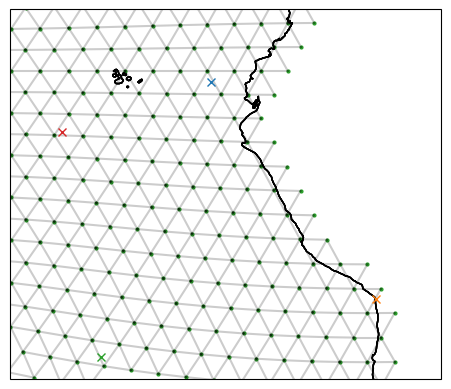

In [4]:
target_ne_corner = ispy.TargetStation("NE Corner", -83.72, -0.928, boundary=True)
target_nw_corner = ispy.TargetStation("NW Corner", -95.794, -4.976, boundary=False)
target_sw_corner = ispy.TargetStation("SW Corner", -92.592, -23.219, boundary=False)
target_se_corner = ispy.TargetStation("SE Corner", -70.285, -18.491, boundary=True)

fig, ax = setup_plot_area_quickstart(ds_IsD)

target_ne_corner.plot(ax=ax, gridlines=False)
target_se_corner.plot(ax=ax, gridlines=False)
target_sw_corner.plot(ax=ax, gridlines=False)
target_nw_corner.plot(ax=ax, gridlines=False)

### The model station
A `TargetStation` will not typically lie exactly on a model grid point. We can convert these stations to model stations as such:

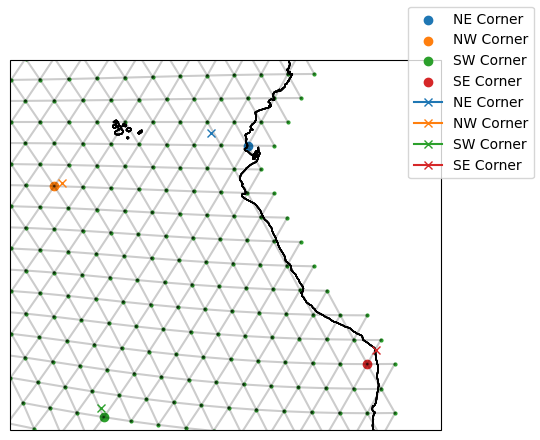

In [9]:
# Convert the target stations to model stations
model_ne_corner = target_ne_corner.to_model_station(ds_IsD)
model_nw_corner = target_nw_corner.to_model_station(ds_IsD)
model_sw_corner = target_sw_corner.to_model_station(ds_IsD)
model_se_corner = target_se_corner.to_model_station(ds_IsD)

fig, ax = setup_plot_area_quickstart(ds_IsD)

# Plot the model stations (circles)
model_ne_corner.plot(ax=ax, gridlines=False)
model_nw_corner.plot(ax=ax, gridlines=False)
model_sw_corner.plot(ax=ax, gridlines=False)
model_se_corner.plot(ax=ax, gridlines=False)

# Compare with the target station (crosses)
target_ne_corner.plot(ax=ax, gridlines=False)
target_nw_corner.plot(ax=ax, gridlines=False)
target_sw_corner.plot(ax=ax, gridlines=False)
target_se_corner.plot(ax=ax, gridlines=False)

fig.legend()

The `ModelStation` uses a "ball tree" to find the nearest vertex on the model grid to it. If we indicate we want a boundary vertex in our `TargetStation`, this will be a point on land. For example, our North East Corner `TargetStation` sits over the ocean (blue cross); however, we have specified we want a boundary vertex so the `ModelStation` we identify is at the coast (blue circle).

Its worth noting that the ball tree understand the Earth's sphericity, so you don't need to worry about using longitudes of [-180, 180) or [0, 360). You will **always** get the closest "valid" point.

If you want to see the index of the vertex of the `ModelStation` you can do so as follows:

In [5]:
model_ne_corner.vertex

4764

## Connect stations to form sections

We construct sections using `ispy.Section`. This is called with a section name, a starting model station and an ending model station, `ds_IsD` which describes the model grid, and a description of type of section we want.

Valid arguments for `section_type` are:
- `"great circle"`: approximates the great circle
- `"shortest"`: the shortest path
- `"contour"`: approximate a contour

In the below we look at how the great circle and shortest paths differ:


In [6]:
ispy.Section?

Init signature:
ispy.Section(
    name,
    model_station_a,
    model_station_b,
    ds_IsD,
    section_type=None,
    contour_target=None,
    contour_data=None,
)
Docstring:      <no docstring>
File:           /work/mh0256/m301014/iconspy/iconspy/core.py
Type:           type
Subclasses:     LandSection, _ReconstructedSection, CombinedSection

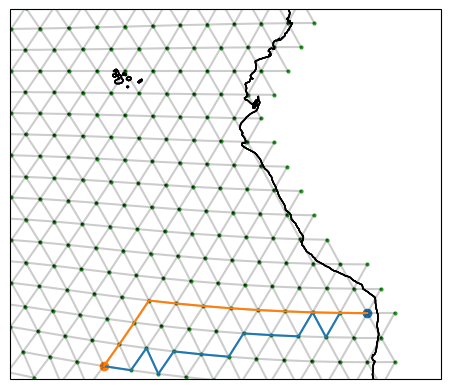

In [7]:
southern_edge_great_circle = ispy.Section(
    "Southern Edge (great circle)",
    model_se_corner,
    model_sw_corner,
    ds_IsD,
    section_type="great circle",
)

southern_edge_shortest = ispy.Section(
    "Southern Edge (shortest)",
    model_se_corner,
    model_sw_corner,
    ds_IsD,
    section_type="shortest",
)

fig, ax = setup_plot_area_quickstart(ds_IsD)
model_se_corner.plot(ax=ax, gridlines=False)
model_sw_corner.plot(ax=ax, gridlines=False)
southern_edge_great_circle.plot(ax=ax, gridlines=False)
southern_edge_shortest.plot(ax=ax, gridlines=False)

The `"great circle"` option approximates the real great circle on the globe, following 13 edges. Meanwhile, the `"shortest path"` finds a route between the start and end points which takes only 11 edges and so is shorter. Notice how the shortest path looks nothing like the great circle!

In [8]:
len(southern_edge_great_circle.edge_path), len(southern_edge_shortest.edge_path)

(13, 11)

When we provide `ModelStation`s to `ispy` and ask it make a section, `ispy` constructs a "graph" representation of the model grid. In this representation the model vertices are treated as nodes and the cell edges which connect them are assigned "weights". Using Djikstra's algorithm, we then identify the path between the two `ModelStation`s which minimises the sum of the weights from the edges traversed. When we look for the `"shortest path"` the weights used are just the length of the edges. When we use the `"great circle"`, `ispy` calculates the theoretical great circle with the weights corresponding to the distance of a particular edge from this line.



We can also try and define sections which approximate bathymetry contours. To do this we need points which start and end near the contours we want to examine, and preferrably well defined bathymetry. Given the coarseness of the R2B4 grid this may look funny, but the method comes into its own on higher resolution grids.

Let's see if we can create a section which approximates the bathmetry of the mid-Atlantic ridge.

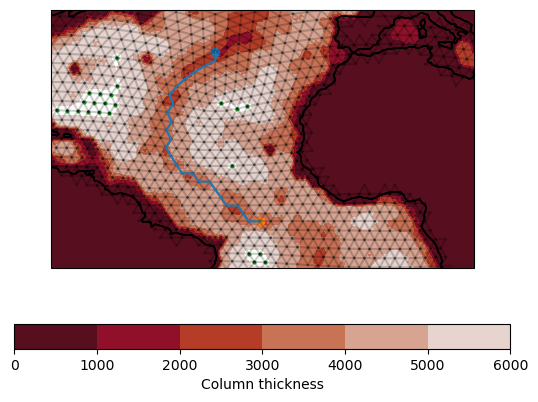

In [33]:
# Define our targer stations for the Mid-Atlantic Ridge section and convert them to model stations
target_mar_n = ispy.TargetStation("MAR North", -34.0, 36.0, boundary=False)
target_mar_s = ispy.TargetStation("MAR South", -26.4, 0.0, boundary=False)

model_mar_n = target_mar_n.to_model_station(ds_IsD)
model_mar_s = target_mar_s.to_model_station(ds_IsD)

# Create a contour section
mar_contour = ispy.Section(
    "Mid-Atlantic Ridge (contour)",
    model_mar_n,
    model_mar_s,
    ds_IsD,
    section_type="contour",
    contour_data=ds_fx["column_thick_e"],
    contour_target=2000,
)


# Let's see how we did!
fig, ax = setup_plot_area_mar(ds_IsD)

cax = ax.tricontourf(
    ds_IsD["elon"],
    ds_IsD["elat"],
    ds_fx["column_thick_e"],
    cmap=cmo.amp_r,
    levels=[0, 1000, 2000, 3000, 4000, 5000, 6000],
)


model_mar_n.plot(ax=ax, gridlines=False)
model_mar_s.plot(ax=ax, gridlines=False)

mar_contour.plot(ax=ax, gridlines=False)

fig.colorbar(cax, ax=ax, label="Column thickness", orientation="horizontal")

Looks like we did pretty well!

We can get the orientation of edges along a path by running the below:

In [7]:
great_circle.set_pyic_orientation_along_path(ds_IsD)
great_circle.edge_orientation

<xarray.DataArray 'edge' (step_in_path: 13)> Size: 104B
array([ 1.,  1.,  1.,  1.,  1.,  1., -1., -1., -1., -1., -1., -1., -1.])
Coordinates:
  * step_in_path  (step_in_path) int32 52B 3531 3529 3521 ... 3795 3790 3789
    elon          (step_in_path) float64 104B -34.4 -34.4 ... -35.59 -35.59
    elat          (step_in_path) float64 104B 14.33 12.65 ... -2.533 -4.222
    edge          (step_in_path) int32 52B 10010 9802 9798 ... 10547 10543 10531

## Connect sections to form a region

In [8]:
example_region = ispy.Region("Offshore of the Amazon", [shortest, great_circle, contour], ds_IsD)

/work/mh0256/m301014/iconspy/iconspy/utils.py:125: UserWarning: rename 'step_in_path_v' to 'step_in_path' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  edge_path_xr = edge_path_xr.rename(step_in_path_v="step_in_path")
/work/mh0256/m301014/iconspy/iconspy/utils.py:36: UserWarning: rename 'step_in_path_v' to 'step_in_path' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  vertex_path = vertex_path.rename(step_in_path_v="step_in_path")


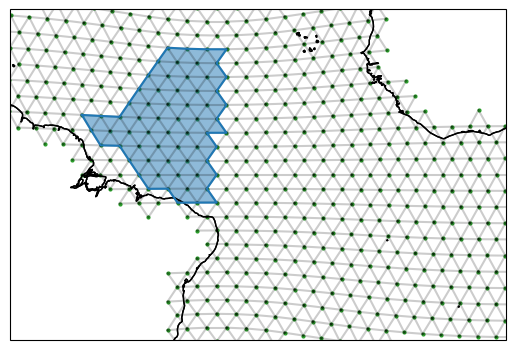

In [9]:
fig, ax = setup_plot_area(ds_IsD)
example_region.plot(ax=ax, gridlines=False)

Regions have paths of edges and also edge orientations that we can use for calcualting fluxes into the region

In [10]:
print(example_region.edge_circuit)
print(example_region.path_orientation)

<xarray.DataArray 'edge' (step_in_path: 32)> Size: 128B
array([ 7752, 10079, 10113, 10097, 10108,  9853, 10062, 10049, 10065, 10006,
       10010,  9802,  9798,  9782,  9789,  9872,  9866,  9864,  9878,  9882,
       10547, 10543, 10535, 10760, 10756, 10763, 10748, 10086, 10085, 10121,
       10125,  7793], dtype=int32)
Coordinates:
    step_in_path  (step_in_path) int64 256B 1 2 3 4 5 6 7 ... 27 28 29 30 31 32
    elon          (step_in_path) float64 256B -50.17 -47.89 ... -49.62 -50.74
    elat          (step_in_path) float64 256B 7.166 7.053 7.848 ... 4.455 6.295
    edge          (step_in_path) int32 128B 7752 10079 10113 ... 10125 7793
<xarray.DataArray (step_in_path: 32)> Size: 256B
array([-1.,  1., -1.,  1., -1.,  1., -1., -1.,  1., -1.,  1.,  1.,  1.,
        1.,  1.,  1., -1., -1., -1., -1., -1., -1., -1.,  1.,  1.,  1.,
       -1.,  1.,  1., -1.,  1., -1.])
Coordinates:
  * step_in_path  (step_in_path) int64 256B 1 2 3 4 5 6 7 ... 27 28 29 30 31 32
    elon          (step_in_

Regions also have a list of the cells contained by them

In [11]:
example_region.contained_cells

<xarray.DataArray 'cell' (cell: 94)> Size: 376B
array([4941, 6248, 6250, 6251, 6256, 6258, 6259, 6260, 6261, 6262, 6263, 6280,
       6281, 6282, 6283, 6284, 6285, 6286, 6287, 6288, 6289, 6291, 6292, 6293,
       6294, 6295, 6297, 6299, 6300, 6301, 6302, 6303, 6305, 6390, 6426, 6435,
       6436, 6437, 6438, 6440, 6441, 6442, 6443, 6444, 6445, 6446, 6447, 6448,
       6449, 6450, 6451, 6452, 6453, 6454, 6455, 6456, 6457, 6459, 6460, 6461,
       6462, 6463, 6465, 6471, 6476, 6477, 6478, 6486, 6487, 6488, 6489, 6490,
       6491, 6492, 6493, 6494, 6495, 6496, 6497, 6498, 6499, 6500, 6501, 6731,
       6868, 6869, 6870, 6872, 6874, 6875, 6876, 6877, 6878, 6879], dtype=int32)
Coordinates:
  * cell     (cell) int32 376B 4941 6248 6250 6251 6256 ... 6876 6877 6878 6879
    clon     (cell) float64 752B -50.2 -35.0 -36.19 ... -38.55 -36.18 -37.37
    clat     (cell) float64 752B 6.618 8.872 9.691 ... -0.4345 -0.4301 -2.123

We can also create a dataset representation of the region to be saved to a netcdf file for subsequent use.

In [12]:
example_region.to_ispy_section("test.nc", dryrun=True)  # set dryrun=False to actually save the file.

Output will be saved to test.nc
Not saving as dryrun=True


<xarray.Dataset> Size: 4kB
Dimensions:           (step_in_path: 32, step_in_path_v: 33, cell: 94)
Coordinates:
  * step_in_path      (step_in_path) int64 256B 1 2 3 4 5 6 ... 28 29 30 31 32
  * cell              (cell) int32 376B 4941 6248 6250 6251 ... 6877 6878 6879
    elon              (step_in_path) float64 256B -50.17 -47.89 ... -50.74
    elat              (step_in_path) float64 256B 7.166 7.053 ... 4.455 6.295
    edge              (step_in_path) int32 128B 7752 10079 10113 ... 10125 7793
    vlon              (step_in_path_v) float64 264B -51.3 -49.04 ... -51.3
    vlat              (step_in_path_v) float64 264B 7.224 7.106 ... 5.365 7.224
    vertex            (step_in_path_v) int32 132B 2835 2837 3618 ... 2848 2835
    clon              (cell) float64 752B -50.2 -35.0 -36.19 ... -36.18 -37.37
    clat              (cell) float64 752B 6.618 8.872 9.691 ... -0.4301 -2.123
Dimensions without coordinates: step_in_path_v
Data variables:
    edge_path         (step_in_path) int32 128B 7752 10079 10113 ... 10125 7793
    vertex_path       (step_in_path_v) int32 132B 2835 2837 3618 ... 2848 2835
    path_orientation  (step_in_path) float64 256B -1.0 1.0 -1.0 ... 1.0 -1.0
    contained_cells   (cell) int32 376B 4941 6248 6250 6251 ... 6877 6878 6879
Attributes:
    date:     2026-01-29 15:10:18

## Reconstruct sections from a region
Having produced a region we can also extract the sections that make it up. This can be useful as ordinary sections don't have edge orientations.

In [13]:
reconstructed_sections = example_region.extract_sections_from_region(ds_IsD)

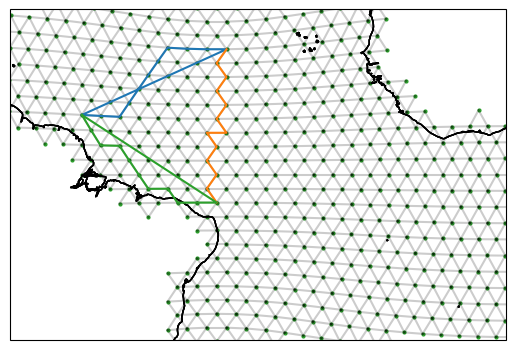

In [14]:
fig, ax = setup_plot_area(ds_IsD)
for section in reconstructed_sections:
    reconstructed_sections[section].plot(ax=ax, gridlines=False)

In the above we can see a funny straight line in the blue and green section. This is a bug that will be adressed in a future version. It arises from the repeating of the first vertex along the section at the end of the section. The edge paths remain unaffected though.